# <b>lec06. 딥러닝 CNN - 숫자 이미지 분류
* https://www.kaggle.com/competitions/Kannada-MNIST/data
* https://www.kaggle.com/competitions/digit-recognizer/data #위에꺼 막혀서 여기서 가 아니라 애초에 케글노트북에서 돌려야 점수산출가능

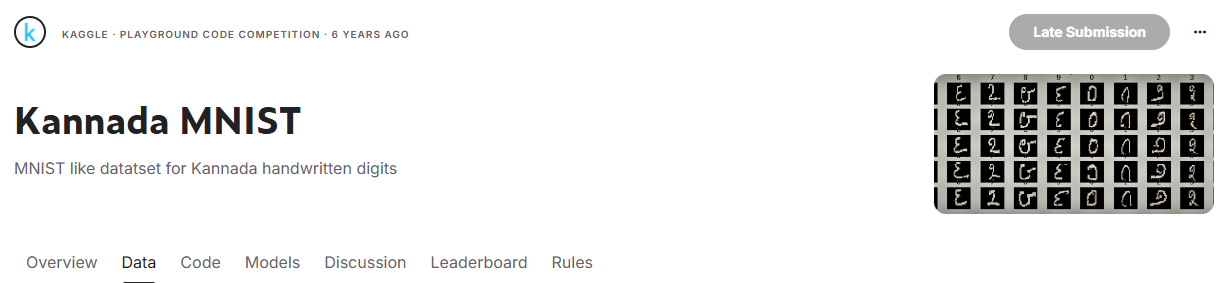

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split                     

#----------------------------------------------------------------------------------  DL모델 
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense, Conv2D, MaxPooling2D, GlobalAveragePooling2D #CNN
from tensorflow.keras.layers import  Flatten, Rescaling #일반 딥러닝

from tensorflow.keras.initializers import GlorotNormal #Xavier가 GlorotNormal로 바뀜
from tensorflow.keras.applications import MobileNetV2  #최소 이미지 크기 (32*32)

#----------------------------------------------------------------------------------  조기종료
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

#----------------------------------------------------------------------------------  랜덤 시드 고정
import tensorflow as tf
tf.random.set_seed(54546)
np.random.seed(54546)

#----------------------------------------------------------------------------------  EDA : 이미지로드
from tensorflow.keras.utils import load_img, img_to_array
from PIL import Image
from tensorflow.keras.utils import image_dataset_from_directory

import warnings
warnings.filterwarnings('ignore')

sns.set()

#-------------------- 차트 관련 속성 (한글처리, 그리드) -----------
plt.rcParams['font.family']= 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

#-------------------- 주피터 , 출력결과 넓이 늘리기 ---------------
# from IPython.core.display import display, HTML
from IPython.display import display, HTML
display(HTML("<style>.container{width:100% !important;}</style>"))
pd.set_option('display.max_rows', 100)
pd.set_option('display.max_columns', 100)
pd.set_option('max_colwidth', None)

# <b> DATA load

In [2]:
train = pd.read_csv(r"C:\IT\workspace_ptyhon\dl\train.csv")
test = pd.read_csv(r"C:\IT\workspace_ptyhon\dl\test.csv")
sample_sub = pd.read_csv(r"C:\IT\workspace_ptyhon\dl\sample_submission.csv")

In [3]:
train.head()

,label,pixel0,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,pixel10,pixel11,pixel12,pixel13,pixel14,pixel15,pixel16,pixel17,pixel18,pixel19,pixel20,pixel21,pixel22,pixel23,pixel24,pixel25,pixel26,pixel27,pixel28,pixel29,pixel30,pixel31,pixel32,pixel33,pixel34,pixel35,pixel36,pixel37,pixel38,pixel39,pixel40,pixel41,pixel42,pixel43,pixel44,pixel45,pixel46,pixel47,pixel48,...,pixel734,pixel735,pixel736,pixel737,pixel738,pixel739,pixel740,pixel741,pixel742,pixel743,pixel744,pixel745,pixel746,pixel747,pixel748,pixel749,pixel750,pixel751,pixel752,pixel753,pixel754,pixel755,pixel756,pixel757,pixel758,pixel759,pixel760,pixel761,pixel762,pixel763,pixel764,pixel765,pixel766,pixel767,pixel768,pixel769,pixel770,pixel771,pixel772,pixel773,pixel774,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783
0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
2,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
3,4,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0


In [4]:
print(train.shape, test.shape)

(42000, 785) (28000, 784)


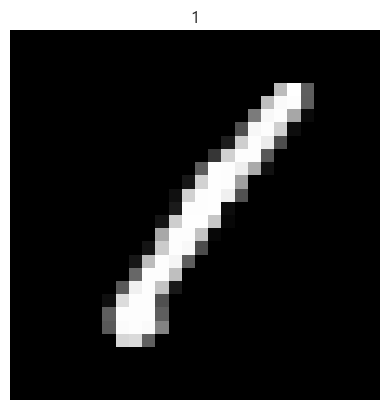

In [5]:
plt.imshow(train.iloc[0,1:].values.reshape(28,28), cmap="gray")
plt.title(train.iloc[0,0])
plt.axis("off")
plt.show()

# <b> EDA

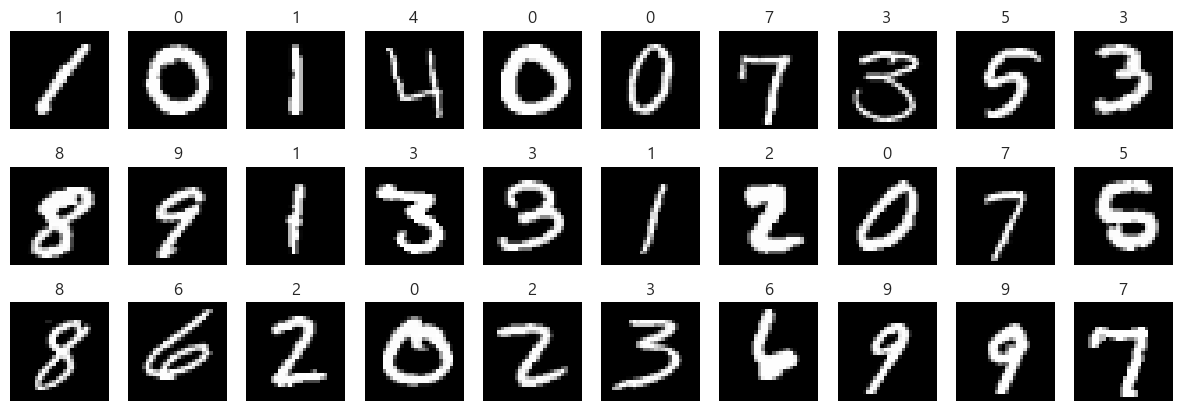

In [6]:
fig, axes = plt.subplots(3,10, figsize=(15,5))

for i in range(30):

    row = i // 10
    col = i % 10

    img = train.iloc[i,1:].values.reshape(28,28)
    label = train.iloc[i,0]

    axes[row][col].imshow(img, cmap="gray")
    axes[row][col].set_title(label)
    axes[row][col].axis("off")

plt.show()

In [7]:
train.iloc[:,1:].min().min()
train.iloc[:,1:].max().max()

np.int64(255)

In [8]:
train["label"].value_counts().sort_index()

label
0    4132
1    4684
2    4177
3    4351
4    4072
5    3795
6    4137
7    4401
8    4063
9    4188
Name: count, dtype: int64

# <b> 전처리&가공

In [9]:
X = train.drop("label", axis=1).values
y = train["label"].values

test_X = test.values

# <b> 정규화

In [10]:
X = X / 255.0
test_X = test_X / 255.0

In [11]:
X = X.reshape(-1, 28, 28, 1)
test_X = test_X.reshape(-1, 28, 28, 1)
from tensorflow.keras.utils import to_categorical
y = to_categorical(y, 10)

# <b> 보정처리

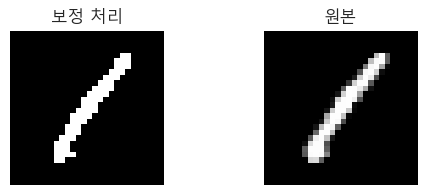

In [12]:
th = 0.5

X_bin = np.where(X > th, 1.0, 0.0)
test_X_bin = np.where(test_X > th, 1.0, 0.0)
plt.figure(figsize=(6,2))

plt.subplot(1,2,1)
plt.imshow(X_bin[0].reshape(28,28), cmap='gray')
plt.title("보정 처리")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(X[0].reshape(28,28), cmap='gray')
plt.title("원본")
plt.axis("off")

plt.show()

# <b> X,y분리

In [13]:
X_train, X_val, y_train, y_val = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=np.argmax(y, axis=1)
)

# <b> 모델

In [14]:
model = Sequential([
    
    Conv2D(32, (3,3), activation="relu", input_shape=(28,28,1)),
    MaxPooling2D((2,2)),
    
    Conv2D(64, (3,3), activation="relu"),
    MaxPooling2D((2,2)),
    
    Conv2D(128, (3,3), activation="relu"), 
    
    Flatten(),
    Dense(128, activation="relu"),
    
    Dense(10, activation="softmax")
])

model.compile( optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

In [15]:
model.summary() 

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 26, 26, 32)          │             320 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 13, 13, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 11, 11, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 5, 5, 64)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_2 (Conv2D)                    │ (None, 3, 3, 128)           │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 1152)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 128)                 │         147,584 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 10)                  │           1,290 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 241,546 (943.54 KB)

 Trainable params: 241,546 (943.54 KB)

 Non-trainable params: 0 (0.00 B)

In [16]:
fit_res = model.fit(
    X_train, y_train,
    epochs=10,
    batch_size=64,
    validation_data=(X_val, y_val)
)
loss, acc = model.evaluate(X_val, y_val)
print(f"val_acc: {acc:.4f}, val_loss: {loss:.4f}")

Epoch 1/10
525/525 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - accuracy: 0.9286 - loss: 0.2312 - val_accuracy: 0.9795 - val_loss: 0.0674
Epoch 2/10
525/525 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.9817 - loss: 0.0568 - val_accuracy: 0.9845 - val_loss: 0.0478
Epoch 3/10
525/525 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - accuracy: 0.9882 - loss: 0.0374 - val_accuracy: 0.9877 - val_loss: 0.0413
Epoch 4/10
525/525 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - accuracy: 0.9901 - loss: 0.0292 - val_accuracy: 0.9868 - val_loss: 0.0436
Epoch 5/10
525/525 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - accuracy: 0.9929 - loss: 0.0216 - val_accuracy: 0.9873 - val_loss: 0.0443
Epoch 6/10
525/525 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - accuracy: 0.9944 - loss: 0.0165 - val_accuracy: 0.9882 - val_loss: 0.0426
Epoch 7/10
525/525 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.9961 - loss: 0.0132 - val_accuracy: 0.9867 - val_loss: 0.0542
Epoch 8/10
525/525 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - accuracy: 0.9959 - loss: 0.0124 - val_accuracy: 0.

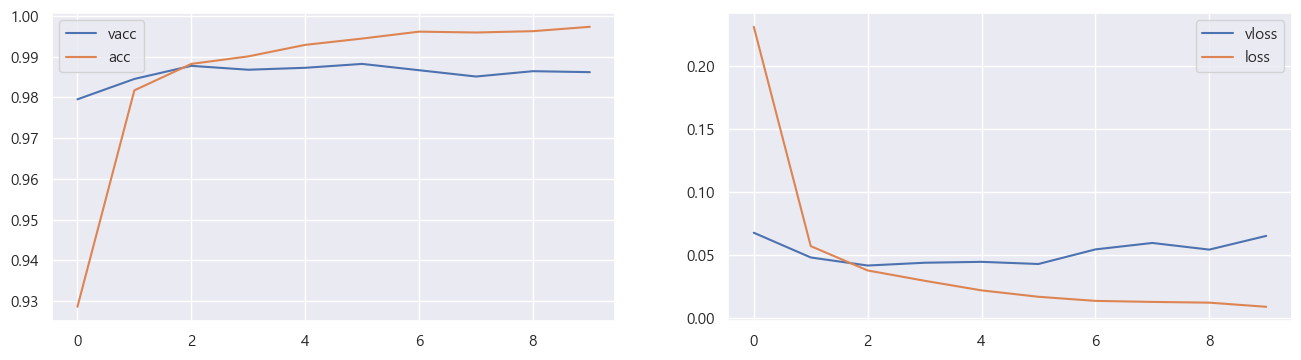

In [17]:
plt.figure(figsize=(16,4))
plt.subplot(1,2,1)
vacc = fit_res.history["val_accuracy"]
acc  = fit_res.history["accuracy"]
plt.plot(range(10), vacc , label="vacc")
plt.plot(range(10), acc  , label="acc")
plt.legend()

plt.subplot(1,2,2)
vloss = fit_res.history["val_loss"]
loss = fit_res.history["loss"]
plt.plot(range(10),vloss , label="vloss")
plt.plot(range(10),loss  , label="loss")
plt.legend()
plt.show()

In [18]:
pred = model.predict(test_X, verbose=0)
pred_label = np.argmax(pred, axis=1)

In [19]:
MY_EARLY_STOP = EarlyStopping(
    monitor="val_loss",     
    patience=3,
    restore_best_weights=True
)

In [20]:
MY_CHECK_POINT = ModelCheckpoint(
                "./models/lec06_CNN_{epoch}_{val_accuracy:.4f}_{val_loss:.4f}.keras",                 
                monitor="val_accuracy",     
                save_best_only=True,     
                save_weights_only=False,  
)

In [21]:
fit_res = model.fit(
    X_train, y_train,
    epochs=20,
    batch_size=64,
    validation_data=(X_val, y_val),
    callbacks=[MY_EARLY_STOP, MY_CHECK_POINT]
)

Epoch 1/20
525/525 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - accuracy: 0.9967 - loss: 0.0107 - val_accuracy: 0.9890 - val_loss: 0.0505
Epoch 2/20
525/525 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - accuracy: 0.9974 - loss: 0.0080 - val_accuracy: 0.9881 - val_loss: 0.0509
Epoch 3/20
525/525 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - accuracy: 0.9971 - loss: 0.0089 - val_accuracy: 0.9877 - val_loss: 0.0678
Epoch 4/20
525/525 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - accuracy: 0.9981 - loss: 0.0056 - val_accuracy: 0.9869 - val_loss: 0.0620


# <b>BEST Model

In [23]:
from tensorflow.keras.models import load_model
best_model = load_model("lec06_CNN_1_0.9890_0.0505.keras")
best_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 26, 26, 32)          │             320 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 13, 13, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 11, 11, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 5, 5, 64)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_2 (Conv2D)                    │ (None, 3, 3, 128)           │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 1152)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 128)                 │         147,584 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 10)                  │           1,290 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 724,640 (2.76 MB)

 Trainable params: 241,546 (943.54 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 483,094 (1.84 MB)

In [24]:
loss, acc = best_model.evaluate(X_val, y_val)
print(f"val_acc : {acc:.4f}, val_loss : {loss:.4f}")

263/263 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9890 - loss: 0.0505
val_acc : 0.9890, val_loss : 0.0505


In [25]:
pred = best_model.predict(test_X, verbose=0)
pred_label = np.argmax(pred, axis=1)

## 답안제출

In [26]:
submission = pd.DataFrame({
    "ImageId": np.arange(1, len(pred_label)+1),
    "Label": pred_label
})

submission.to_csv("submission.csv", index=False)
print("submission.csv 저장 완료")

submission.csv 저장 완료


In [27]:
submission.head()

,ImageId,Label
0,1,2
1,2,0
2,3,9
3,4,9
4,5,3


In [28]:
submission.shape

(28000, 2)

In [30]:
submission["Label"].unique()

array([2, 0, 9, 3, 7, 5, 4, 1, 6, 8])

# <b>이미지 증강

```python
from tensorflow.keras import layers
from tensorflow.keras.models import Sequential

data_aug = Sequential([
layers.RandomFlip("horizontal"),
layers.RandomRotation(0.1),
layers.RandomZoom(0.1),
layers.RandomContrast(0.1)
])

model = 